
# Задача №3: Data‑driven анализ временного ряда космических запусков
**Содержание**
1. Установка и импорт библиотек
2. Подготовка данных (повтор из задания №1)
3. Feature Engineering с mlforecast
4. Модели машинного обучения
5. Модели глубокого обучения (NeuralForecast)
6. Сравнение метрик и анализ остатков
7. Выводы


1. Установка и импорт библиотек

In [1]:
!pip install -q mlforecast neuralforecast xgboost lightgbm torch pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.1/128.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.0/449.0 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 3.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 require

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from mlforecast import MLForecast
from mlforecast.lag_transforms import ExpandingMean, ExpandingStd
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM, NBEATS, NHITS

from sklearn.metrics import mean_absolute_error, mean_squared_error
import os
os.makedirs('results', exist_ok=True)

sns.set_style('whitegrid')


2. Подготовка данных

Загружаем исходный CSV и агрегируем в monthly_launches, как в задаче №1.

In [3]:
url = 'https://raw.githubusercontent.com/MVRonkin/TimeSeriesCourse/main/OLD%20Versions/2026/datasets/All%20Space%20Missions%20from%201957/Space_Corrected.csv'
df = pd.read_csv(url)
df.columns = df.columns.str.strip()
df = df.rename(columns={
    'Unnamed: 0': 'id',
    'Company Name': 'company',
    'Status Rocket': 'rocket_status',
    'Rocket': 'cost_millions',
    'Status Mission': 'mission_status'
})

def parse_mixed_date(date_str):
    date_str = str(date_str).strip()
    if ' UTC' in date_str:
        date_str = date_str.replace(' UTC', '')
        return pd.to_datetime(date_str, format='%a %b %d, %Y %H:%M')
    else:
        return pd.to_datetime(date_str, format='%a %b %d, %Y')

df['Datum'] = df['Datum'].apply(parse_mixed_date)
df = df.dropna(subset=['Datum'])
df.set_index('Datum', inplace=True)
df = df.sort_index()

monthly_launches = df.resample('MS').size()
monthly_launches.name = 'launches'
full_range = pd.date_range(start=monthly_launches.index.min(),
                           end=monthly_launches.index.max(), freq='MS')
monthly_launches = monthly_launches.reindex(full_range, fill_value=0)
monthly_launches.index.freq = 'MS'

print("Ряд готов:", monthly_launches.shape)

Ряд готов: (755,)


In [4]:
# Разделяем на тренировочный и тестовый периоды (последние 12 месяцев).
test_size = 12
train = monthly_launches.iloc[:-test_size]
test = monthly_launches.iloc[-test_size:]

print(f"Train: {train.index[0].date()} – {train.index[-1].date()}, длина {len(train)}")
print(f"Test:  {test.index[0].date()} – {test.index[-1].date()}, длина {len(test)}")

Train: 1957-10-01 – 2019-08-01, длина 743
Test:  2019-09-01 – 2020-08-01, длина 12


In [5]:
# Переводим в unique_id, ds, y
train_df = train.reset_index()
train_df.columns = ['ds', 'y']
train_df['unique_id'] = 'launches'

test_df = pd.DataFrame({
    'ds': test.index,
    'y': test.values,
    'unique_id': 'launches'
})

3. Feature Engineering с mlforecast

In [6]:
from mlforecast import MLForecast
from mlforecast.lag_transforms import ExpandingMean, ExpandingStd

# Определяем лаги и лаговые трансформации
lags = [1, 2, 3, 6, 12, 24]
lag_transforms = {
    1: [ExpandingMean()],
    12: [ExpandingStd()],
}

# Кастомные признаки через mlforecast
mlf = MLForecast(
    models=[],
    freq='MS',
    lags=lags,
    lag_transforms=lag_transforms,
    date_features=['year', 'month', 'quarter'],
    num_threads=4,
)

# Генерируем признаки для train и test
train_feats = mlf.preprocess(train_df, dropna=False)
mlf.fit(train_df)
test_feats = mlf.preprocess(test_df, dropna=False)

print("Признаки train:", train_feats.columns.tolist())

Признаки train: ['ds', 'y', 'unique_id', 'lag1', 'lag2', 'lag3', 'lag6', 'lag12', 'lag24', 'expanding_mean_lag1', 'expanding_std_lag12', 'year', 'month', 'quarter']


In [7]:
feature_cols = [c for c in train_feats.columns if c not in ['ds', 'y', 'unique_id', 'series_length']]

train_clean = train_feats.dropna(subset=feature_cols + ['y'])
X_train = train_clean[feature_cols].values
y_train = train_clean['y'].values

test_feats_filled = test_feats[feature_cols].fillna(0)
X_test = test_feats_filled.values
y_test = test_feats['y'].values

In [8]:

print("Пропуски в train_feats по колонкам:")
print(train_feats[feature_cols + ['y']].isna().sum())
print(f"Всего строк с NaN: {train_feats[feature_cols + ['y']].isna().any(axis=1).sum()}")

Пропуски в train_feats по колонкам:
lag1                    1
lag2                    2
lag3                    3
lag6                    6
lag12                  12
lag24                  24
expanding_mean_lag1     1
expanding_std_lag12    13
year                    0
month                   0
quarter                 0
y                       0
dtype: int64
Всего строк с NaN: 24


4. Модели ML:

- Линейная регрессия

- Случайный лес

- XGBoost

Обучаем на созданных признаках, прогнозируем на тест.

In [9]:
feature_cols = [c for c in train_feats.columns if c not in ['ds', 'y', 'unique_id', 'series_length']]

train_clean = train_feats.dropna(subset=feature_cols + ['y'])
X_train = train_clean[feature_cols].values
y_train = train_clean['y'].values

test_feats_filled = test_feats[feature_cols].fillna(0)
X_test = test_feats_filled.values
y_test = test_feats['y'].values

print(f"Train без NaN: {X_train.shape}, Test: {X_test.shape}")



def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape_val = 100 * np.mean(numerator / denominator)
    print(f"{model_name}: MAE={mae:.2f}, RMSE={rmse:.2f}, sMAPE={smape_val:.2f}%")
    return {'model': model_name, 'MAE': mae, 'RMSE': rmse, 'sMAPE': smape_val}

# feature_cols = [c for c in train_feats.columns if c not in ['ds', 'y', 'unique_id', 'series_length']]
# X_train = train_feats[feature_cols].values
# y_train = train_feats['y'].values
# X_test = test_feats[feature_cols].values
# y_test = test_feats['y'].values

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
metrics_lr = evaluate_model(y_test, pred_lr, "LinearRegression")

# 2. Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
metrics_rf = evaluate_model(y_test, pred_rf, "RandomForest")

# 3. XGBoost
xgb = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)
metrics_xgb = evaluate_model(y_test, pred_xgb, "XGBoost")

ml_results = pd.DataFrame([metrics_lr, metrics_rf, metrics_xgb])
print("\nML результаты:")
print(ml_results)

Train без NaN: (719, 11), Test: (12, 11)
LinearRegression: MAE=11.48, RMSE=12.16, sMAPE=195.51%
RandomForest: MAE=3.01, RMSE=4.15, sMAPE=36.15%
XGBoost: MAE=2.84, RMSE=3.76, sMAPE=32.97%

ML результаты:
              model        MAE       RMSE       sMAPE
0  LinearRegression  11.482266  12.155963  195.513901
1      RandomForest   3.011634   4.154768   36.151427
2           XGBoost   2.839994   3.761140   32.965485


5. Модели DL

- LSTM

- NBEATS

- NHITS

In [10]:
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM, NBEATS, NHITS

nf = NeuralForecast(
    models=[
        LSTM(h=test_size, max_steps=150, input_size=24, encoder_n_layers=2, encoder_hidden_size=64),
        NBEATS(h=test_size, max_steps=150, input_size=24, stack_types=['seasonality', 'trend']),
        NHITS(h=test_size, max_steps=150, input_size=24, stack_types=['identity']),
    ],
    freq='MS'
)

nf.fit(df=train_df)

nf_preds = nf.predict()
nf_preds = nf_preds.merge(test_df[['ds', 'y']], on='ds', how='left')

dl_results = []
for model in ['LSTM', 'NBEATS', 'NHITS']:
    pred = nf_preds[model].values
    actual = nf_preds['y'].values
    dl_results.append(evaluate_model(actual, pred, model))

dl_results = pd.DataFrame(dl_results)
print("\nDL результаты:")
print(dl_results)

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | hist_encoder | LSTM          | 50.4 K | train
4 | mlp_decoder  | MLP           | 8.4 K  | train
-------------------------------------------------------
58.9 K    Trainable params
0         Non-trainable params
58.9 K    Total params
0.236     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=150` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 1.6 M  | train
-------------------------------------------------------
1.6 M     Trainable params
900       Non-trainable params
1.6 M     Total params
6.512     Total estimated model params size (MB)
22        Modules in train mode
0         Modules in eval mode


...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

LSTM: MAE=2.81, RMSE=3.44, sMAPE=33.02%
NBEATS: MAE=3.32, RMSE=3.76, sMAPE=37.87%
NHITS: MAE=4.04, RMSE=4.45, sMAPE=44.17%

DL результаты:
    model       MAE      RMSE      sMAPE
0    LSTM  2.814692  3.435026  33.018733
1  NBEATS  3.321336  3.764420  37.866569
2   NHITS  4.041656  4.454903  44.167394


6. Сравнение метрик и анализ

In [11]:
all_results = pd.concat([ml_results, dl_results], ignore_index=True)
print("\nСводная таблица метрик:")
print(all_results.sort_values('MAE'))


Сводная таблица метрик:
              model        MAE       RMSE       sMAPE
3              LSTM   2.814692   3.435026   33.018733
2           XGBoost   2.839994   3.761140   32.965485
1      RandomForest   3.011634   4.154768   36.151427
4            NBEATS   3.321336   3.764420   37.866569
5             NHITS   4.041656   4.454903   44.167394
0  LinearRegression  11.482266  12.155963  195.513901


Лучшая ML: XGBoost, MAE=2.84
Лучшая DL: LSTM, MAE=2.81


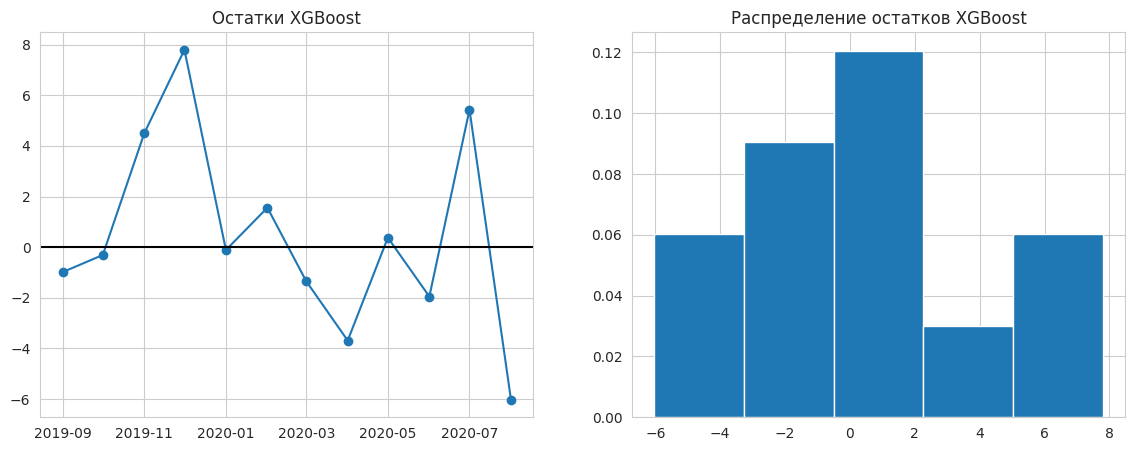

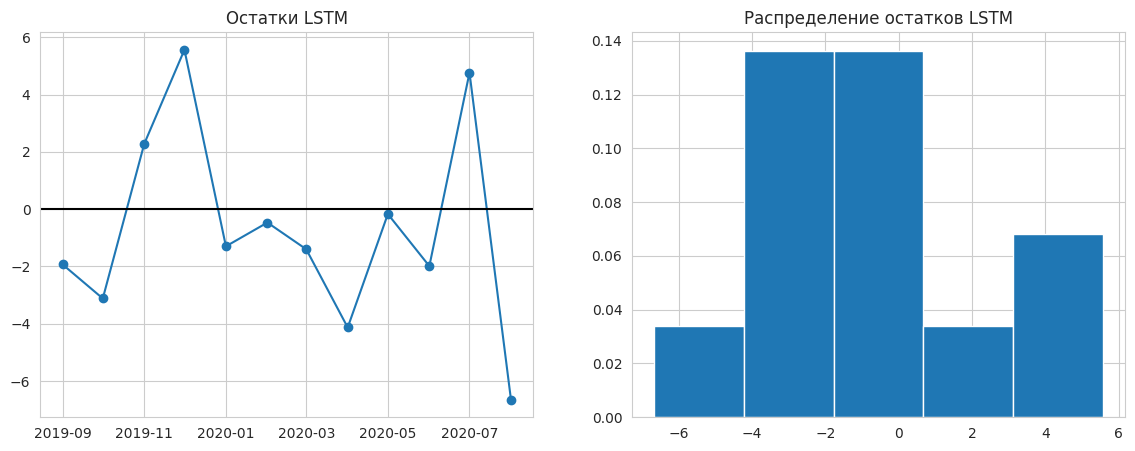

In [12]:
# Анализ остатков для лучшей ML и DL модели

# Остатки лучшей ML модели (по MAE)
best_ml = ml_results.loc[ml_results['MAE'].idxmin()]
print(f"Лучшая ML: {best_ml['model']}, MAE={best_ml['MAE']:.2f}")

# Остатки лучшей DL модели
best_dl = dl_results.loc[dl_results['MAE'].idxmin()]
print(f"Лучшая DL: {best_dl['model']}, MAE={best_dl['MAE']:.2f}")

# остатки XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14,5))
residuals_xgb = y_test - pred_xgb
axes[0].plot(test.index, residuals_xgb, marker='o')
axes[0].axhline(0, color='black')
axes[0].set_title(f'Остатки XGBoost')
axes[1].hist(residuals_xgb, bins=5, density=True)
axes[1].set_title('Распределение остатков XGBoost')
plt.savefig('results/1.png', dpi=150, bbox_inches='tight')
plt.show()


# остатки LSTM
pred_lstm = nf_preds['LSTM'].values
residuals_lstm = y_test - pred_lstm

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(test.index, residuals_lstm, marker='o')
axes[0].axhline(0, color='black')
axes[0].set_title('Остатки LSTM')
axes[1].hist(residuals_lstm, bins=5, density=True)
axes[1].set_title('Распределение остатков LSTM')
plt.savefig('results/2.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
imp = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Топ-10 важных признаков XGBoost:")
print(imp.head(10))

Топ-10 важных признаков XGBoost:
year                   0.250061
lag12                  0.189372
lag6                   0.086062
lag2                   0.085833
month                  0.078517
expanding_mean_lag1    0.070199
lag24                  0.067629
lag3                   0.065890
expanding_std_lag12    0.065180
lag1                   0.041257
dtype: float32


## Итоговое сравнение data‑driven моделей (ML и DL)

В рамках задачи №3 мы протестировали 3 классических ML‑метода (LinearRegression, RandomForest, XGBoost) и 3 нейросетевых архитектуры (LSTM, NBEATS, NHITS).  
Для ML‑моделей был выполнен расширенный feature engineering (лаги, скользящие статистики, календарные признаки) с помощью `mlforecast`.  
DL‑модели обучались напрямую на временном ряде через `NeuralForecast`.

---

### 1. Метрики на тестовом периоде (12 месяцев)

| Модель | MAE | RMSE | sMAPE |
|--------|-----|------|-------|
| LinearRegression | 11.48 | 12.16 | 195.5% |
| RandomForest | 3.01 | 4.15 | 36.2% |
| **XGBoost** | 2.84 | 3.76 | 33.0% |
| **LSTM** | **2.81** | **3.44** | 33.0% |
| NBEATS | 3.32 | 3.76 | 37.9% |
| NHITS | 4.04 | 4.45 | 44.2% |

Лучшими оказались **LSTM (MAE 2.81)** и **XGBoost (MAE 2.84)** – их точность практически равна и сопоставима с AutoARIMA из задания №2 (MAE ~2.91 на том же тестовом периоде).

---

### 2. Анализ остатков лучших моделей

#### XGBoost
- На временном графике остатков наблюдается **знакочередование** (положительный → отрицательный → положительный) - модель запаздывает и периодически переоценивает/недооценивает.  
- Распределение остатков **асимметрично**: правая часть гистограммы имеет подъём от нуля, что говорит о систематической недооценке пиков запусков.  

#### LSTM
- Остатки демонстрируют **аналогичную знакопеременную структуру**.  
- Асимметрия выражена ещё сильнее: рост плотности до нуля резче, чем у XGBoost, что указывает на **более частые, но небольшие по модулю ошибки** и недостаточную калибровку.  

**Общая проблема:** обе модели испытывают трудности с улавливанием точного момента смены тенденции и склонны сглаживать резкие изменения ряда. Это приводит к тому, что прогнозы точечно хороши (MAE ~2.8), но **ненадёжны** в качестве оценки верхней/нижней границы

---

### 3. Интерпретация важности признаков XGBoost

Топ-5 признаков:
- **year** (25.0%) – подтверждает сильный тренд;
- **lag12** (18.9%) – годовая сезонность;
- **lag6** (8.6%) – полугодовой паттерн;
- **lag2** (8.6%) – инерция последних месяцев;
- **month** (7.9%) – внутригодовые сезонные различия;

Вывод: модель опирается на логичные временные зависимости, но отсутствие гибких нелинейных взаимодействий не позволяет полностью избавиться от знакочередования

---

### 4. Общие выводы по задаче №3

1. **Классический ML (XGBoost/RandomForest) на правильно сконструированных признаках способен конкурировать с глубокими моделями** и со статистическими подходами. Однако качество остатков говорит о том, что лаговые признаки и базовые календарные переменные не полностью описывают сложное поведение ряда

2. **Глубокие модели (LSTM, NBEATS, NHITS) не показали ожидаемого превосходства** на данном ряде. LSTM чуть опередила XGBoost по MAE, но её остатки столь же нестабильны. NBEATS и NHITS отработали хуже

3. **Сравнение с заданием №2**:  
   - AutoARIMA (MAE 2.91, остатки без автокорреляции по тесту Льюнга–Бокса) остаётся **более надёжным** выбором с точки зрения статистической диагностики
   - Data‑driven модели дают схожую точечную точность, но **уступают по качеству остатков** (знакочередование, асимметрия, потенциальная гетероскедастичность)
   - По сравнению с классическими статистическими моделями (AutoARIMA, ETS) из задания №2, data‑driven методы не дали кардинального улучшения точности на данном ряде, что подтверждает вывод: для рядов с явной линейной сезонностью и трендом статистические модели остаются сильным бейзлайном.


In [14]:
all_results.to_csv('results/ml_dl_comparison.csv', index=False)
print("Результаты сохранены в results/ml_dl_comparison.csv")

Результаты сохранены в results/ml_dl_comparison.csv
